In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [4]:
rfm = pd.read_csv(r"C:\Users\Zulkarnain Yawar\Downloads\processed_customer_rfm.csv")
print("Dataset loaded")
rfm


Dataset loaded


,CustomerID,Recency,Frequency,Monetary
0,AA-10315,8,42,13747.41300
1,AA-10375,6,42,5884.19500
2,AA-10480,125,38,17695.58978
3,AA-10645,28,73,15343.89070
4,AA-315,2,8,2243.25600
...,...,...,...,...
1585,YS-21880,9,54,18703.60600
1586,ZC-11910,200,1,7.17300
1587,ZC-21910,3,84,28472.81926
1588,ZD-11925,3,18,2951.22600


In [5]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,AA-10315,8,42,13747.41300
1,AA-10375,6,42,5884.19500
2,AA-10480,125,38,17695.58978
3,AA-10645,28,73,15343.89070
4,AA-315,2,8,2243.25600


In [6]:
features = rfm[['Recency','Frequency','Monetary']]

In [43]:
rfm[['Recency','Frequency','Monetary']] = np.log1p(rfm[['Recency','Frequency','Monetary']])

In [44]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print("Feature Scaling Completed")



Feature Scaling Completed


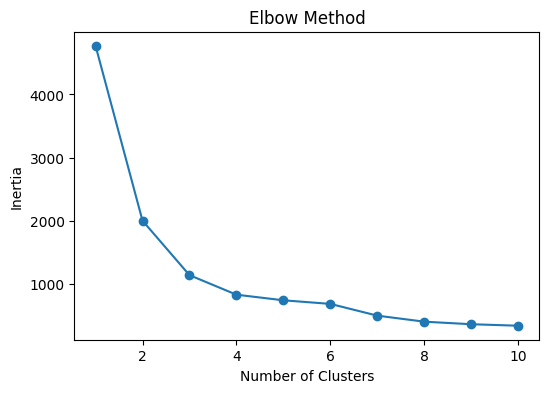

In [45]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

K = range(1,11)

for k in K:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [46]:
from sklearn.metrics import silhouette_score

for k in range(2,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(scaled_features, labels)
    
    print("Clusters:", k, "Silhouette Score:", score)

Clusters: 2 Silhouette Score: 0.5599682819270465
Clusters: 3 Silhouette Score: 0.5736930962198578
Clusters: 4 Silhouette Score: 0.49022384116050083
Clusters: 5 Silhouette Score: 0.44436989810350747
Clusters: 6 Silhouette Score: 0.37586398247267455
Clusters: 7 Silhouette Score: 0.39681637717731505
Clusters: 8 Silhouette Score: 0.377170880150588
Clusters: 9 Silhouette Score: 0.3561900156784451


In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(scaled_features)

In [48]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

print(cluster_summary)

          Recency  Frequency  Monetary
Cluster                               
0        5.965198   2.175218  6.925762
1        2.844016   3.975698  9.521989
2        3.815704   2.645171  7.497012


In [49]:
cluster_names = {
    
    0: "Lost Customers",
    1: "Champions",
    2: "Loyal Customers"

}

rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_names)

In [50]:
cluster_summary = rfm.groupby('Customer_Segment')[['Recency','Frequency','Monetary']].mean()

print(cluster_summary)

                   Recency  Frequency  Monetary
Customer_Segment                               
Champions         2.844016   3.975698  9.521989
Lost Customers    5.965198   2.175218  6.925762
Loyal Customers   3.815704   2.645171  7.497012


In [52]:
print(rfm["Customer_Segment"].value_counts())

Customer_Segment
Champions          741
Loyal Customers    700
Lost Customers     149
Name: count, dtype: int64


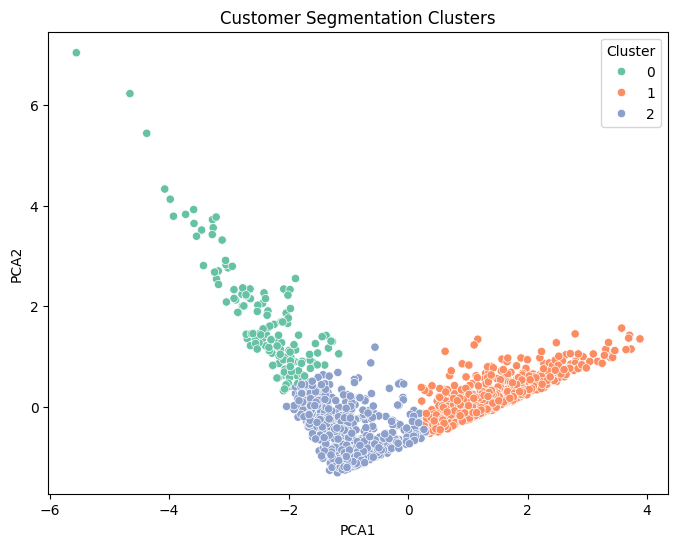

In [51]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=rfm,
    palette='Set2'
)

plt.title("Customer Segmentation Clusters")

plt.show()

In [53]:
rfm.to_csv("customer_segments.csv", index=False)